In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
from faker import Faker
import random
faker=Faker()
data=[]
cities = ["New York", "Chicago", "Los Angeles", "Houston", "San Francisco"]
ride_status_list = ["Completed", "Cancelled", "No Show"]
for _ in range(500):
    data.append({
       "ride_id": faker.uuid4(),
        "city": random.choice(cities),
        "hour": random.randint(0, 23),  
        "fare": round(random.uniform(5, 50), 2),  
        "ride_status": random.choice(ride_status_list)
    })

    df=pd.DataFrame(data)
    df.to_csv("ride_sharing.csv")

In [17]:
df.head()

,ride_id,city,hour,fare,ride_status
0,3245f20b-2745-4827-acd6-483bc63642da,Los Angeles,0,6.34,No Show
1,c0dfbfcc-7730-4db0-9653-55954826f190,Houston,7,8.53,Cancelled
2,0eeadc9e-cfcd-442e-97fb-a439a44336d7,Chicago,10,42.54,Cancelled
3,cd4671d5-6d98-488f-8834-ac97f2c89ee4,Los Angeles,9,23.63,Cancelled
4,6d3dc7a1-15c7-4864-a43b-b48d4ca16eef,San Francisco,1,19.18,No Show


In [18]:
peak_hours = (
    df.groupby(['city','hour'])
      .size()
      .groupby(level=0)
      .idxmax()
)

print(peak_hours)

city
Chicago                (Chicago, 14)
Houston                 (Houston, 7)
Los Angeles         (Los Angeles, 2)
New York              (New York, 23)
San Francisco    (San Francisco, 22)
dtype: object


In [19]:
cancel_percent=(df['ride_status']=='Cancelled').mean()*100
print(cancel_percent)

36.199999999999996


In [20]:
demand_index=df.groupby('hour').size().values
base=demand_index[0]
de=(demand_index/base)*100
de


array([100.        ,  78.26086957, 117.39130435,  86.95652174,
       104.34782609, 100.        ,  95.65217391, 104.34782609,
        78.26086957,  69.56521739,  82.60869565,  60.86956522,
       130.43478261,  43.47826087,  91.30434783, 113.04347826,
        82.60869565,  73.91304348,  86.95652174,  95.65217391,
        60.86956522,  86.95652174, 113.04347826, 117.39130435])

In [21]:
smooth = np.convolve(demand_index, np.ones(3)/3, mode='valid')

print(smooth)

[22.66666667 21.66666667 23.66666667 22.33333333 23.         23.
 21.33333333 19.33333333 17.66666667 16.33333333 21.         18.
 20.33333333 19.         22.         20.66666667 18.66666667 19.66666667
 18.66666667 18.66666667 20.         24.33333333]


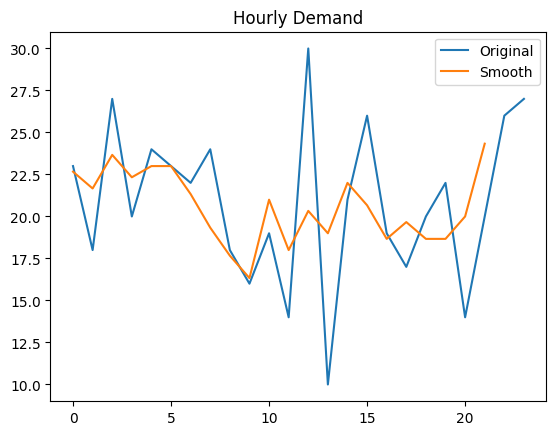

In [22]:
plt.plot(demand_index, label='Original')
plt.plot(smooth, label='Smooth')

plt.legend()
plt.title("Hourly Demand")
plt.show()

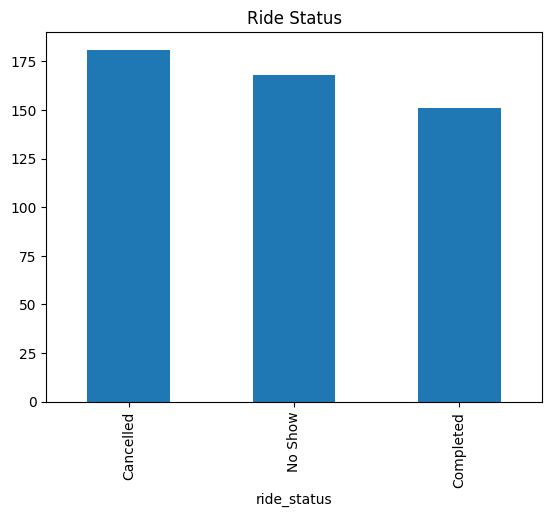

In [23]:
df['ride_status'].value_counts().plot(kind='bar')

plt.title("Ride Status")
plt.show()